In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing import image

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import cv2
import os

from sklearn.metrics import confusion_matrix, classification_report

In [4]:
data_dir = "weed/train"

IMG_SIZE = 224
BATCH_SIZE = 32

classes = [
    'carpetweeds',
    'crabgrass',
    'eclipta',
    'goosegrass',
    'morningglory'
]

In [5]:
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1765
)

In [6]:
import os
import shutil

train_dir = "weed/train"
test_dir = "weed/Test"

valid_classes = [
    "carpetweeds",
    "crabgrass",
    "eclipta",
    "goosegrass",
    "morningglory"
]

def remove_unknown_folders(path):
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)

        # Check only folders
        if os.path.isdir(folder_path):
            if folder not in valid_classes:
                print(f"Removing unwanted folder: {folder}")
                shutil.rmtree(folder_path)


remove_unknown_folders(train_dir)
remove_unknown_folders(test_dir)

print("Unknown folders removed successfully!")

Unknown folders removed successfully!


In [7]:
train_data = train_val_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)



Found 1675 images belonging to 5 classes.


In [8]:
val_data = train_val_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)


Found 356 images belonging to 5 classes.


In [9]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

test_data = test_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 302 images belonging to 5 classes.


In [10]:
print("======================================")
print("DATASET SPLIT INFORMATION")
print("======================================")

print("Training Images :", train_data.samples)
print("Validation Images :", val_data.samples)
print("Testing Images :", test_data.samples)

total_images = (
    train_data.samples +
    val_data.samples +
    test_data.samples
)

print("\nTotal Images :", total_images)

print("\nClass Names :")
print(train_data.class_indices)

print("\nTotal Classes :", len(train_data.class_indices))


DATASET SPLIT INFORMATION
Training Images : 1675
Validation Images : 356
Testing Images : 302

Total Images : 2333

Class Names :
{'carpetweeds': 0, 'crabgrass': 1, 'eclipta': 2, 'goosegrass': 3, 'morningglory': 4}

Total Classes : 5


In [11]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
  
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  

    layers.Dense(5, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\yalam\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.3248 - loss: 1.6221 - val_accuracy: 0.4185 - val_loss: 1.4236
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.3875 - loss: 1.4079 - val_accuracy: 0.4017 - val_loss: 1.3239
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.4501 - loss: 1.3043 - val_accuracy: 0.4522 - val_loss: 1.2481
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.4913 - loss: 1.2292 - val_accuracy: 0.4831 - val_loss: 1.1666
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.5493 - loss: 1.1430 - val_accuracy: 0.5309 - val_loss: 1.1843
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.5504 - loss: 1.1298 - val_accuracy: 0.6011 - val_loss: 1.0289
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5899 - loss: 1.0421 - val_accuracy: 0.6124 - val_loss: 1.0540
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6078 - loss: 0.9632 - val_accuracy: 0.6180 - val_loss

In [13]:
loss, accuracy = cnn_model.evaluate(test_data)

print("CNN Test Accuracy:", accuracy)
print("CNN Test Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.6589 - loss: 1.0464
CNN Test Accuracy: 0.6589403748512268
CNN Test Loss: 1.0463745594024658


In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)  

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.4997 - loss: 1.3499 - val_accuracy: 0.7556 - val_loss: 0.7482
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7325 - loss: 0.6935 - val_accuracy: 0.8090 - val_loss: 0.5220
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7624 - loss: 0.5849 - val_accuracy: 0.7949 - val_loss: 0.5200
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7928 - loss: 0.5227 - val_accuracy: 0.8764 - val_loss: 0.3625
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8018 - loss: 0.5110 - val_accuracy: 0.8624 - val_loss: 0.3709
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8263 - loss: 0.4601 - val_accuracy: 0.8680 - val_loss: 0.3791
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8364 - loss: 0.4248 - val_accuracy: 0.8652 - val_loss: 0.3909
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8400 - loss: 0.4159 - val_accuracy: 0.8792 - val_loss:

In [16]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.7982 - loss: 0.6031 - val_accuracy: 0.8539 - val_loss: 0.4310
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8937 - loss: 0.2786 - val_accuracy: 0.8848 - val_loss: 0.3570
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9254 - loss: 0.1969 - val_accuracy: 0.9101 - val_loss: 0.2809
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9475 - loss: 0.1592 - val_accuracy: 0.9213 - val_loss: 0.2773
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9612 - loss: 0.1140 - val_accuracy: 0.8933 - val_loss: 0.4166
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9660 - loss: 0.0987 - val_accuracy: 0.9213 - val_loss: 0.2958
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9743 - loss: 0.0884 - val_accuracy: 0.9466 - val_loss: 0.2349
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9743 - loss: 0.0791 - val_accuracy: 0.9382 - val_loss:

In [17]:
loss, accuracy = transfer_model.evaluate(test_data)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 876ms/step - accuracy: 0.9338 - loss: 0.2229
Test Accuracy: 0.9337748289108276
Test Loss: 0.22289228439331055


In [18]:
efficient_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

efficient_base.trainable = False

efficient_model = models.Sequential([
    efficient_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(5, activation='softmax')
])

efficient_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_efficient = efficient_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.2167 - loss: 1.6238 - val_accuracy: 0.2219 - val_loss: 1.6146
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.2287 - loss: 1.6021 - val_accuracy: 0.2219 - val_loss: 1.5862
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.2221 - loss: 1.5919 - val_accuracy: 0.2219 - val_loss: 1.5853
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.2191 - loss: 1.5917 - val_accuracy: 0.2219 - val_loss: 1.5847
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.2239 - loss: 1.5894 - val_accuracy: 0.2219 - val_loss: 1.5862
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.2167 - loss: 1.5909 - val_accuracy: 0.2219 - val_loss: 1.5831
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.2245 - loss: 1.5891 - val_accuracy: 0.2219 - val_loss: 1.5827
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.2221 - loss: 1.5889 - val_accuracy: 0.2949 - val_loss

In [ ]:
efficient_base.trainable = True


layer.trainable = False  

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_efficient_fine = efficient_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

In [18]:
loss, accuracy = efficient_model.evaluate(test_data)

print("efficient_model Test Accuracy:", accuracy)
print("efficient_model Test Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 849ms/step - accuracy: 0.2219 - loss: 1.5808
efficient_model Test Accuracy: 0.2218542993068695
efficient_model Test Loss: 1.580849051475525


In [35]:
transfer_model.save("weed_detection_model.h5")

print("Model saved successfully!")

Model saved successfully!


Evaluating CNN Model...
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step
Evaluating MobileNetV2 Model...
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 702ms/step
Evaluating EfficientNetB0 Model...
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 845ms/step
MODEL COMPARISON TABLE
            Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
0             CNN         57.95          63.16       57.95         58.16
1     MobileNetV2         91.72          92.23       91.72         91.66
2  EfficientNetB0         22.19           4.92       22.19          8.06


C:\Users\yalam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yalam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yalam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yalam\anaconda3\Lib

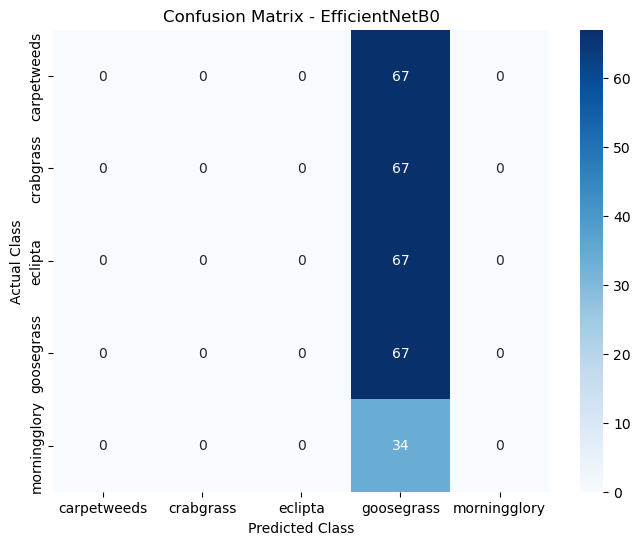

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
print("Evaluating CNN Model...")
cnn_pred = cnn_model.predict(test_data)
cnn_pred_classes = np.argmax(cnn_pred, axis=1)

print("Evaluating MobileNetV2 Model...")
mobile_pred = transfer_model.predict(test_data)
mobile_pred_classes = np.argmax(mobile_pred, axis=1)

print("Evaluating EfficientNetB0 Model...")
efficient_pred = efficient_model.predict(test_data)
efficient_pred_classes = np.argmax(efficient_pred, axis=1)

true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return [
        round(acc * 100, 2),
        round(pre * 100, 2),
        round(rec * 100, 2),
        round(f1 * 100, 2)
    ]

results = pd.DataFrame({
    "Model": [
        "CNN",
        "MobileNetV2",
        "EfficientNetB0"
    ],
    "Accuracy (%)": [
        get_metrics(true_classes, cnn_pred_classes)[0],
        get_metrics(true_classes, mobile_pred_classes)[0],
        get_metrics(true_classes, efficient_pred_classes)[0]
    ],
    "Precision (%)": [
        get_metrics(true_classes, cnn_pred_classes)[1],
        get_metrics(true_classes, mobile_pred_classes)[1],
        get_metrics(true_classes, efficient_pred_classes)[1]
    ],
    "Recall (%)": [
        get_metrics(true_classes, cnn_pred_classes)[2],
        get_metrics(true_classes, mobile_pred_classes)[2],
        get_metrics(true_classes, efficient_pred_classes)[2]
    ],
    "F1 Score (%)": [
        get_metrics(true_classes, cnn_pred_classes)[3],
        get_metrics(true_classes, mobile_pred_classes)[3],
        get_metrics(true_classes, efficient_pred_classes)[3]
    ]
})

print("MODEL COMPARISON TABLE")
print(results)


cm = confusion_matrix(true_classes, efficient_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - EfficientNetB0")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


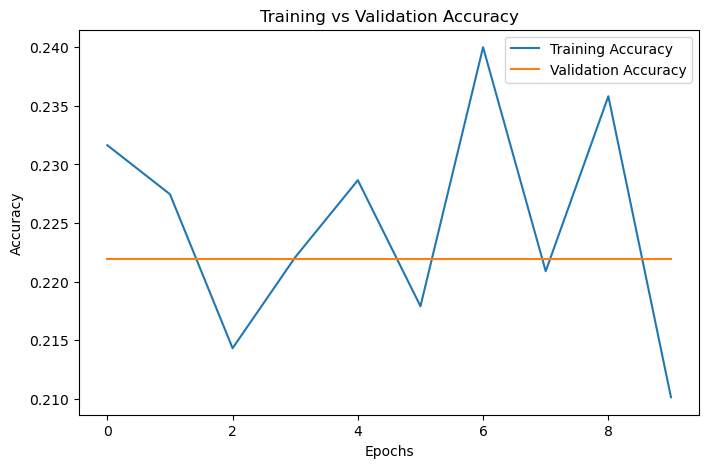

In [38]:
#PLOT TRAINING vs VALIDATION ACCURACY

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_efficient_fine.history['accuracy'], label='Training Accuracy')
plt.plot(history_efficient_fine.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

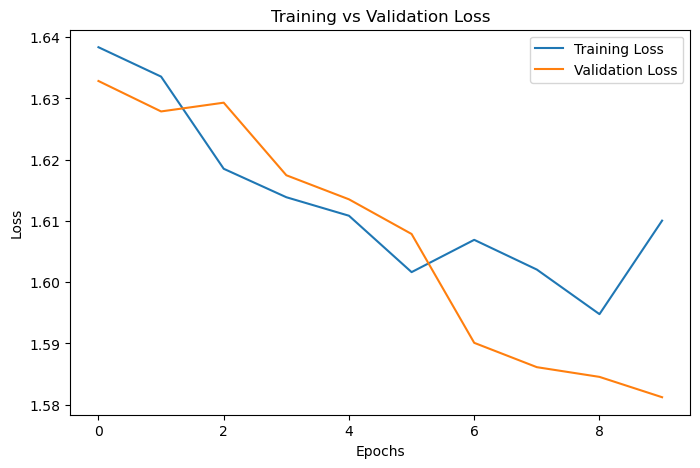

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history_efficient_fine.history['loss'], label='Training Loss')
plt.plot(history_efficient_fine.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [40]:
val_loss, val_accuracy = efficient_model.evaluate(val_data)

print("\n====================================")
print("VALIDATION RESULTS")
print("====================================")

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_accuracy * 100, 2), "%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 958ms/step - accuracy: 0.2219 - loss: 1.5812

VALIDATION RESULTS
Validation Loss: 1.5812
Validation Accuracy: 22.19 %


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


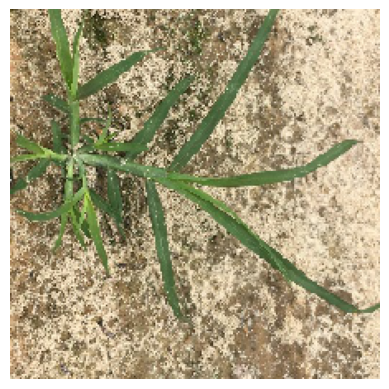

Predicted Class: goosegrass


In [41]:
img_path = r"C:\Users\yalam\Downloads\Weed\Weed\train\cotton_weed\Goosegrass\Goosegrass_2.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = transfer_model.predict(img_array)

class_index = np.argmax(prediction)

plt.imshow(img)
plt.axis("off")
plt.show()

print("Predicted Class:", classes[class_index])

In [42]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

In [43]:
model = load_model("weed_detection_model.h5")

In [44]:
classes = [
    'carpetweeds',
    'crabgrass',
    'eclipta',
    'goosegrass',
    'morningglory'
]



In [45]:
def detect_weed(img_path): 
    IMG_SIZE = 224
    threshold = 0.70  
    img = image.load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    confidence = np.max(prediction)
    class_index = np.argmax(prediction)
    if confidence > threshold:
        print("🌱 WEED DETECTED")
        print("Predicted Weed Type:", classes[class_index])
        print("Confidence Score:", round(confidence * 100, 2), "%")
    else:
        print("🌾 NO WEED DETECTED")
        print("Likely Normal Crop")
        print("Confidence Score:", round(confidence * 100, 2), "%")

In [46]:
def detect_weed(img_path):

    IMG_SIZE = 224

    # Load image
    img = image.load_img(
        img_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    # Show image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()

    # Preprocess
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)

    confidence = np.max(prediction)
    class_index = np.argmax(prediction)
    predicted_class = classes[class_index]

    # Final Output
    print("🌱 WEED DETECTED")
    print("Predicted Weed Type:", classes[class_index])
    print("Confidence Score:", round(confidence * 100, 2), "%")

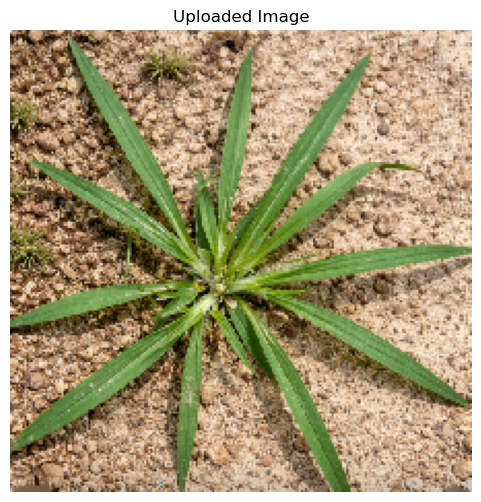

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🌱 WEED DETECTED
Predicted Weed Type: goosegrass
Confidence Score: 100.0 %


In [47]:
detect_weed(r"C:\Users\yalam\Downloads\Screenshot 2026-04-20 181626.png")